In [3]:
#prendo i dati combinati dei vari soggetti
import pandas as pd
subject1 = pd.read_csv('/Users/giuseppebonomo/Desktop/RatioWaveNet/HGD/mental_work_load/S1/hgd_sub1_combined.csv')
subject2 = pd.read_csv('/Users/giuseppebonomo/Desktop/RatioWaveNet/HGD/mental_work_load/S2/hgd_sub2_combined.csv')
subject3 = pd.read_csv('/Users/giuseppebonomo/Desktop/RatioWaveNet/HGD/mental_work_load/S3/hgd_sub3_combined.csv')
subject4 = pd.read_csv('/Users/giuseppebonomo/Desktop/RatioWaveNet/HGD/mental_work_load/S4/hgd_sub4_combined.csv')
subject5 = pd.read_csv('/Users/giuseppebonomo/Desktop/RatioWaveNet/HGD/mental_work_load/S5/hgd_sub5_combined.csv')
subject6 = pd.read_csv('/Users/giuseppebonomo/Desktop/RatioWaveNet/HGD/mental_work_load/S6/hgd_sub6_combined.csv')
subject7 = pd.read_csv('/Users/giuseppebonomo/Desktop/RatioWaveNet/HGD/mental_work_load/S7/hgd_sub7_combined.csv')
subject8 = pd.read_csv('/Users/giuseppebonomo/Desktop/RatioWaveNet/HGD/mental_work_load/S8/hgd_sub8_combined.csv')
subject9 = pd.read_csv('/Users/giuseppebonomo/Desktop/RatioWaveNet/HGD/mental_work_load/S9/hgd_sub9_combined.csv')
subject10 = pd.read_csv('/Users/giuseppebonomo/Desktop/RatioWaveNet/HGD/mental_work_load/S10/hgd_sub10_combined.csv')
subject11 = pd.read_csv('/Users/giuseppebonomo/Desktop/RatioWaveNet/HGD/mental_work_load/S11/hgd_sub11_combined.csv')
subject12 = pd.read_csv('/Users/giuseppebonomo/Desktop/RatioWaveNet/HGD/mental_work_load/S12/hgd_sub12_combined.csv')
subject13 = pd.read_csv('/Users/giuseppebonomo/Desktop/RatioWaveNet/HGD/mental_work_load/S13/hgd_sub13_combined.csv')
subject14 = pd.read_csv('/Users/giuseppebonomo/Desktop/RatioWaveNet/HGD/mental_work_load/S14/hgd_sub14_combined.csv')

# Unisco i dati in un unico DataFrame
combined_data = pd.concat([subject1, subject2, subject3, subject4, subject5, subject6, subject7, subject8, subject9, subject10, subject11, subject12, subject13, subject14], ignore_index=True)

In [4]:
#salvo i dati combinati in un file CSV
combined_data.to_csv('mwl_HGD.csv', index=False)

In [5]:
combined_data

,trial,true_label,pred_label,theta_alpha
0,1,0,0,1.401940
1,2,1,1,1.948437
2,3,2,2,1.090723
3,4,3,3,3.195926
4,5,0,0,0.443820
...,...,...,...,...
2234,156,0,0,1.425163
2235,157,1,1,1.316587
2236,158,0,0,1.210884
2237,159,2,2,0.681747


/var/folders/_7/r_r3pscs7s52j4fc3jqjmv3w0000gn/T/ipykernel_21828/1057458835.py:34: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  tab20 = plt.cm.get_cmap('tab20', 20)


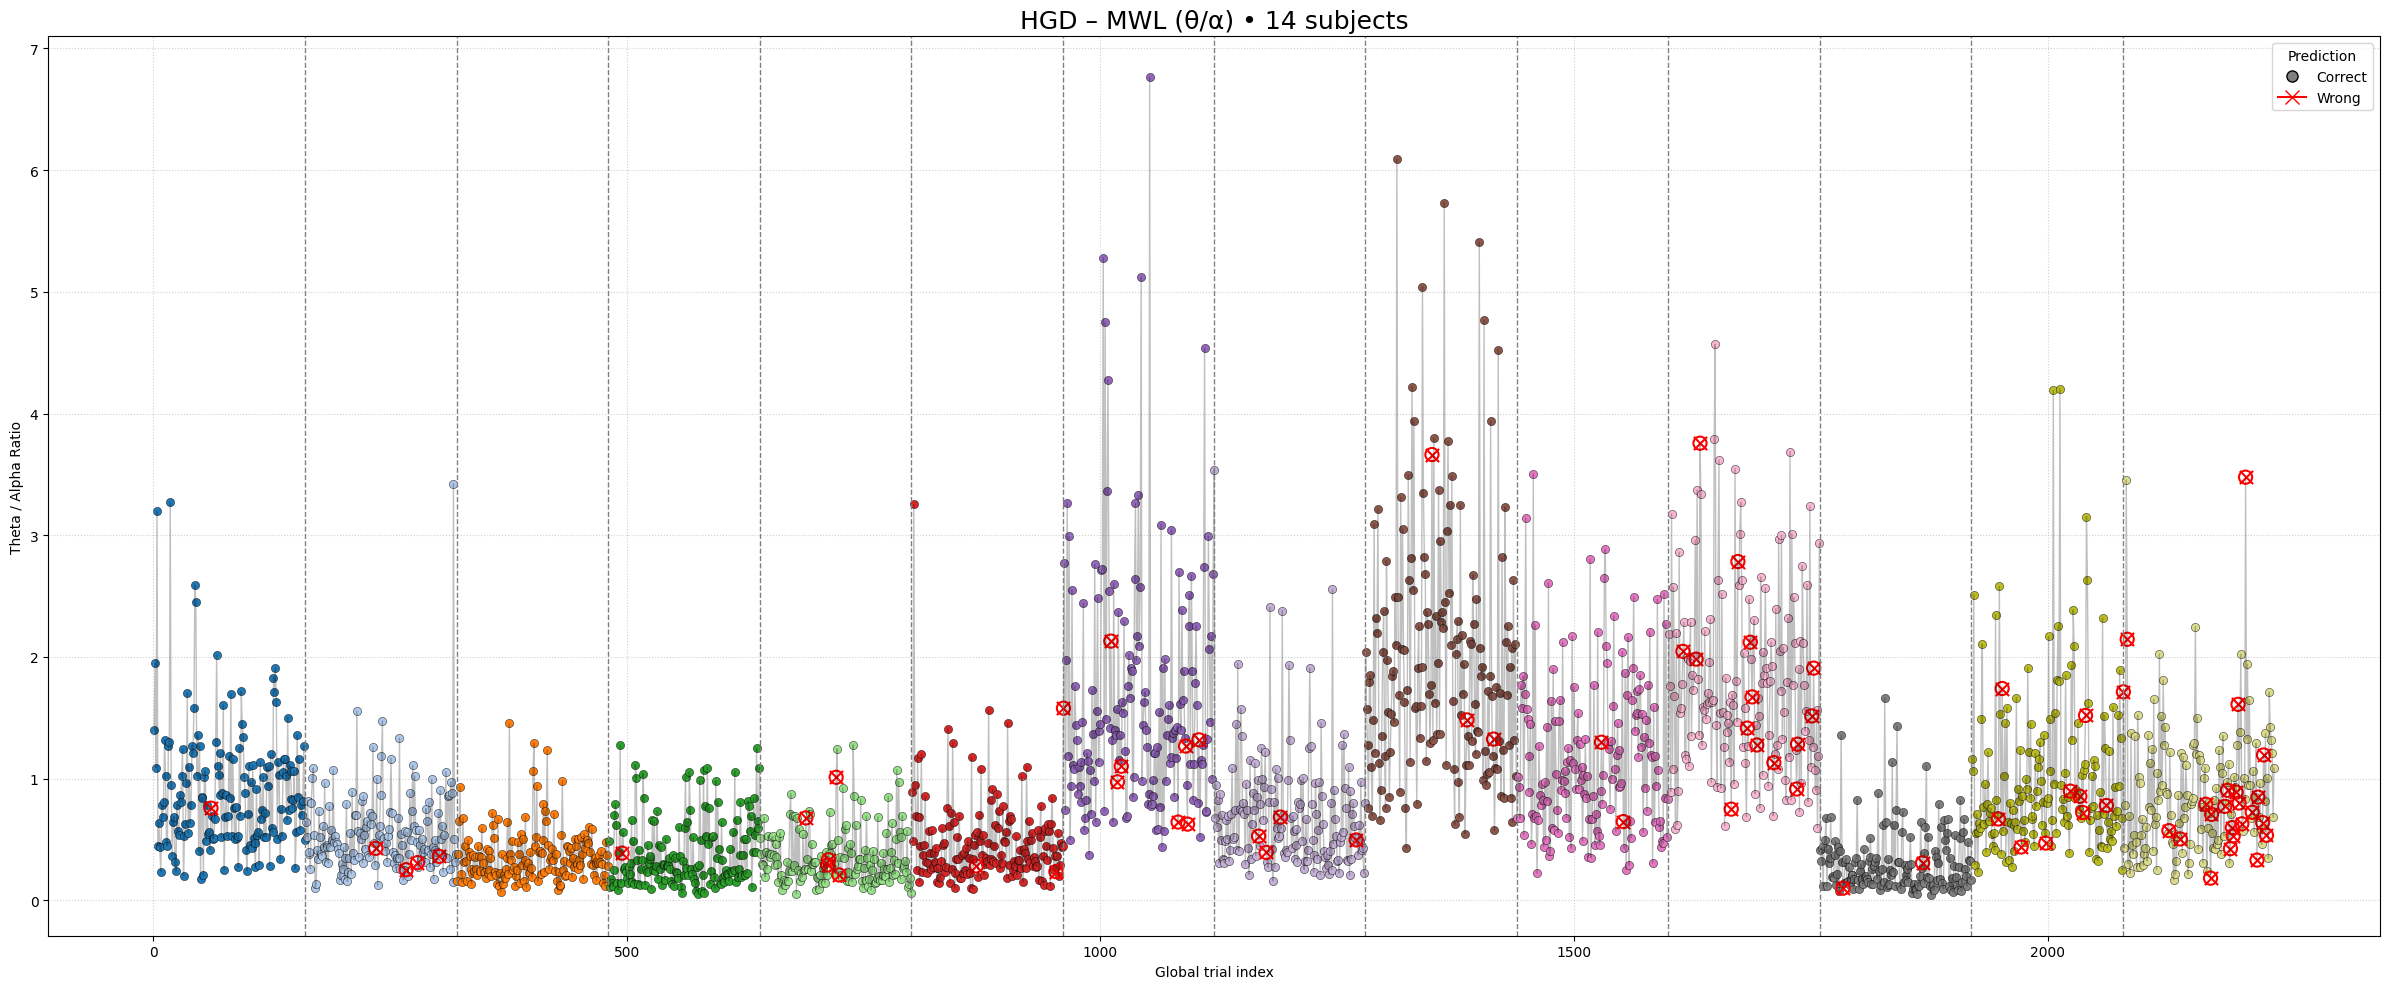

Grafico salvato in 'hgd_mwl_allsubjects.png'


In [14]:
# %% MWL concatenato – HGD  (cerchi rossi+X per Wrong, nessun rosso nei soggetti)

import os, glob, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# ----- 1) carica CSV da S1 … S14 ----------------
dfs, miss = [], []
for sub in range(1, 15):
    csv_p = os.path.join(f"S{sub}", f"hgd_sub{sub}_combined.csv")
    if os.path.exists(csv_p):
        df = pd.read_csv(csv_p); df['subject'] = sub; dfs.append(df)
    else:
        miss.append(sub)
assert dfs, "Nessun CSV trovato"
if miss: print("Senza CSV:", miss)

combined = pd.concat(dfs, ignore_index=True).sort_values(['subject','trial'])

# ----- 2) global_trial ---------------------------
counts = combined.groupby('subject').size().to_dict()
offset, cum = {}, 0
for s in sorted(counts):
    offset[s] = cum; cum += counts[s]
combined['global_trial'] = combined.apply(
    lambda r: r['trial'] + offset[r['subject']], axis=1)

# ----- 3) figura ---------------------------------
fig, ax = plt.subplots(figsize=(24,10))

# palette tab20 escluso i rossi (indici 3,7,11,15,19)
tab20 = plt.cm.get_cmap('tab20', 20)
skip_red = {3,7,11,15,19}
colors = [tab20(i) for i in range(20) if i not in skip_red]
sub_colors = {s: colors[(s-1) % len(colors)] for s in range(1,15)}

# linea θ/α
ax.plot(combined['global_trial'], combined['theta_alpha'],
        color='black', lw=1, alpha=0.25)

# scatter per soggetto
for s, grp in combined.groupby('subject'):
    corr = grp['pred_label'] == grp['true_label']
    # corretti: cerchi pieni color soggetto
    ax.scatter(grp.loc[corr,'global_trial'], grp.loc[corr,'theta_alpha'],
               color=sub_colors[s], s=35, edgecolor='k', linewidths=.3)
    # errati: cerchio vuoto rosso + X rossa
    ax.scatter(grp.loc[~corr,'global_trial'], grp.loc[~corr,'theta_alpha'],
               facecolors='none', edgecolors='red', marker='o',
               s=90, linewidths=1.5)
    ax.scatter(grp.loc[~corr,'global_trial'], grp.loc[~corr,'theta_alpha'],
               color='red', marker='x', s=90, linewidths=1.5)

# divisori soggetto
bounds = np.cumsum([counts[s] for s in sorted(counts)])[:-1]
for b in bounds: ax.axvline(b+.5, ls='--', color='gray', lw=1)

# ----- 4) legenda compatta -----------------------
handles_subj = [Line2D([0],[0], marker='o', color='w',
                       markerfacecolor=sub_colors[s], markeredgecolor='k',
                       markersize=8, label=f'S{s}')
                for s in sorted(counts)]
handles_pred = [
    Line2D([0],[0], marker='o', color='w',
           markerfacecolor='tab:gray', markeredgecolor='k',
           markersize=8, label='Correct'),
    Line2D([0],[0], marker='x', color='red', markersize=10,
           linewidth=1.5, label='Wrong')
]
leg1 = ax.legend(handles_subj, [h.get_label() for h in handles_subj],
                 title='Subject', ncol=7, loc='upper center',
                 bbox_to_anchor=(0.5, 1.13), frameon=False)
ax.add_artist(leg1)
ax.legend(handles_pred, [h.get_label() for h in handles_pred],
          loc='upper right', frameon=True, title='Prediction')

# ----- 5) finitura -------------------------------
ax.set_title("HGD – MWL (θ/α) • 14 subjects", fontsize=18)
ax.set_xlabel("Global trial index"); ax.set_ylabel("Theta / Alpha Ratio")
ax.grid(True, linestyle=':', alpha=.6)
plt.tight_layout()
plt.savefig('hgd_mwl_allsubjects.png', dpi=300)
plt.show()
print("Grafico salvato in 'hgd_mwl_allsubjects.png'")
